**judge-модели:**
- локальная: `mistral-small-3.2-24b-instruct-2506`
- облачная: `qwen/qwen3.5-plus-20260420`

In [ ]:
!pip -q install openai pandas matplotlib tqdm tabulate

**Импорты и базовые настройки**

In [1]:
from __future__ import annotations

import json
import os
import re
import time
from getpass import getpass
from pathlib import Path
from typing import Any, Optional

import matplotlib.pyplot as plt
import pandas as pd
from openai import OpenAI
from tqdm.auto import tqdm


In [2]:
LOCAL_RESULTS_DIR = Path(r"C:\Users\zykan\Downloads\vkr\Judge\local_results\results_vkr_full_experiment")

CLOUD_RESULTS_DIR = Path(r"C:\Users\zykan\Downloads\vkr\Judge\cloud_results\results_vkr_openrouter_experiment")

# новая папка
COMBINED_RESULTS_DIR = Path(r"C:\Users\zykan\Downloads\vkr\Judge\combined_results\results_vkr_combined_judge")

COMBINED_GENERATION_DIR = COMBINED_RESULTS_DIR / "generation"
COMBINED_JUDGE_DIR = COMBINED_RESULTS_DIR / "judge"
COMBINED_PLOTS_DIR = COMBINED_RESULTS_DIR / "plots"

for folder in [COMBINED_GENERATION_DIR, COMBINED_JUDGE_DIR, COMBINED_PLOTS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

LOCAL_GENERATED_PATH = LOCAL_RESULTS_DIR / "generation" / "generated_arguments.csv"
CLOUD_GENERATED_PATH = CLOUD_RESULTS_DIR / "generation" / "generated_arguments.csv"

print("LOCAL_GENERATED_PATH:", LOCAL_GENERATED_PATH, "exists:", LOCAL_GENERATED_PATH.exists())
print("CLOUD_GENERATED_PATH:", CLOUD_GENERATED_PATH, "exists:", CLOUD_GENERATED_PATH.exists())
print("COMBINED_RESULTS_DIR:", COMBINED_RESULTS_DIR)


LOCAL_GENERATED_PATH: C:\Users\zykan\Downloads\vkr\Judge\local_results\results_vkr_full_experiment\generation\generated_arguments.csv exists: True
CLOUD_GENERATED_PATH: C:\Users\zykan\Downloads\vkr\Judge\cloud_results\results_vkr_openrouter_experiment\generation\generated_arguments.csv exists: True
COMBINED_RESULTS_DIR: C:\Users\zykan\Downloads\vkr\Judge\combined_results\results_vkr_combined_judge


**Настройки judge-моделей**

In [4]:
LMSTUDIO_BASE_URL = "http://127.0.0.1:1234/v1"
LMSTUDIO_API_KEY = "lm-studio"

lmstudio_client = OpenAI(
    base_url=LMSTUDIO_BASE_URL,
    api_key=LMSTUDIO_API_KEY,
)

USE_OPENROUTER = True

if USE_OPENROUTER and "OPENROUTER_API_KEY" not in os.environ:
    os.environ["OPENROUTER_API_KEY"] = getpass("Введите OPENROUTER_API_KEY")

openrouter_client = None
if USE_OPENROUTER:
    openrouter_client = OpenAI(
        base_url="https://openrouter.ai/api/v1",
        api_key=os.environ["OPENROUTER_API_KEY"],
        default_headers={
            "HTTP-Referer": "http://localhost",
            "X-OpenRouter-Title": "VKR Combined Judge",
        },
    )

JUDGE_RUNS = [
    {
        "judge_alias": "judge_local_mistral_small_32_24b",
        "backend": "lmstudio",
        "model_id": "mistral-small-3.2-24b-instruct-2506",
        "temperature": 0.0,
        "max_tokens": 450,
    },
    {
        "judge_alias": "judge_cloud_qwen35_plus_20260420",
        "backend": "openrouter",
        "model_id": "qwen/qwen3.5-plus-20260420",
        "temperature": 0.0,
        "max_tokens": 450,
    },
]

In [5]:
pd.DataFrame(JUDGE_RUNS)

,judge_alias,backend,model_id,temperature,max_tokens
0,judge_local_mistral_small_32_24b,lmstudio,mistral-small-3.2-24b-instruct-2506,0.0,450
1,judge_cloud_qwen35_plus_20260420,openrouter,qwen/qwen3.5-plus-20260420,0.0,450


**Критерии оценки**

In [6]:
CRITERIA = [
    "relevance",
    "stance_consistency",
    "argumentativeness",
    "coherence",
    "factual_caution",
    "format_cleanliness",
]

CRITERIA_RU = {
    "relevance": "релевантность тезису",
    "stance_consistency": "соответствие требуемой позиции",
    "argumentativeness": "аргументативность",
    "coherence": "логическая связность",
    "factual_caution": "фактическая осторожность",
    "format_cleanliness": "чистота формата",
}


**очистка reasoning-блоков, JSON, запросы к моделям**

In [7]:
def safe_filename(name: str) -> str:
    name = str(name).strip()
    name = re.sub(r"[\\/:\*\?\"<>\|\s]+", "_", name)
    name = re.sub(r"_+", "_", name)
    return name.strip("_")


def remove_thinking_blocks(text: str) -> str:
    text = str(text)

    # Полные <think>...</think>
    text = re.sub(r"<think>.*?</think>", "", text, flags=re.S | re.I)

    # Непарные теги
    text = re.sub(r"</?think>", "", text, flags=re.I)

    # Служебные токены вида <|...|>
    text = re.sub(r"<\|.*?\|>", "", text)

    return text.strip()


def extract_json_object(text: str) -> Optional[dict[str, Any]]:
    text = remove_thinking_blocks(str(text).strip())

    text = re.sub(r"^```json", "", text, flags=re.I).strip()
    text = re.sub(r"^```", "", text).strip()
    text = re.sub(r"```$", "", text).strip()

    match = re.search(r"\{.*\}", text, flags=re.S)
    if not match:
        return None

    candidate = match.group(0)

    try:
        return json.loads(candidate)
    except json.JSONDecodeError:
        pass

    candidate_fixed = candidate.replace("'", '"')

    try:
        return json.loads(candidate_fixed)
    except json.JSONDecodeError:
        return None


def normalize_score_or_none(value: Any) -> Optional[int]:
    try:
        value = float(value)
    except Exception:
        return None

    value = int(round(value))
    value = max(1, min(5, value))
    return value


def parse_judge_response(raw: str) -> dict[str, Any]:
    data = extract_json_object(raw)

    parsed: dict[str, Any] = {}

    if data is None:
        for criterion in CRITERIA:
            parsed[criterion] = None

        parsed["comment"] = ""
        parsed["judge_parse_ok"] = False
        parsed["raw_judge_response"] = raw
        return parsed

    parse_ok = True

    for criterion in CRITERIA:
        score = normalize_score_or_none(data.get(criterion))
        parsed[criterion] = score

        if score is None:
            parse_ok = False

    parsed["comment"] = str(data.get("comment", "")).strip()
    parsed["judge_parse_ok"] = parse_ok
    parsed["raw_judge_response"] = raw

    return parsed


In [8]:
def chat_complete(
    backend: str,
    model_id: str,
    messages: list[dict[str, str]],
    temperature: float = 0.0,
    top_p: float = 1.0,
    max_tokens: int = 450,
    retries: int = 3,
    pause: float = 2.0,
) -> str:
    if backend == "lmstudio":
        client = lmstudio_client
    elif backend == "openrouter":
        if openrouter_client is None:
            raise RuntimeError("openrouter_client не создан. Проверь OPENROUTER_API_KEY.")
        client = openrouter_client
    else:
        raise ValueError(f"Неизвестный backend: {backend}")

    last_error = None

    for attempt in range(1, retries + 1):
        try:
            response = client.chat.completions.create(
                model=model_id,
                messages=messages,
                temperature=temperature,
                top_p=top_p,
                max_tokens=max_tokens,
            )

            content = response.choices[0].message.content

            if isinstance(content, list):
                text = " ".join(str(x) for x in content)
            else:
                text = content or ""

            text = remove_thinking_blocks(text)

            if text:
                return text.strip()

            time.sleep(pause)

        except Exception as exc:
            last_error = exc
            print(f"[{backend}/{model_id}] Ошибка запроса, попытка {attempt}/{retries}: {exc}")
            time.sleep(pause * attempt)

    if last_error is not None:
        print("Последняя ошибка:", last_error)

    return ""


**Объединение локальной и облачной генерации**

In [9]:
def load_generated_file(path: Path, source_backend: str) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Не найден файл генерации: {path}")

    df = pd.read_csv(path)

    required_cols = {
        "argument_id",
        "model_alias",
        "model_id",
        "task_id",
        "topic",
        "thesis",
        "stance",
        "stance_ru",
        "generated_argument",
    }

    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"В файле {path} нет колонок: {sorted(missing)}")

    df = df.copy()
    df["source_backend"] = source_backend
    df["original_model_alias"] = df["model_alias"].astype(str)
    df["original_argument_id"] = df["argument_id"].astype(str)

    # Уникализируем имена, чтобы локальная и облачная модели с похожими alias не смешались
    df["model_alias"] = source_backend + "__" + df["model_alias"].astype(str)
    df["argument_id"] = source_backend + "__" + df["argument_id"].astype(str)

    return df


local_generated_df = load_generated_file(
    LOCAL_GENERATED_PATH,
    source_backend="local_lmstudio",
)

cloud_generated_df = load_generated_file(
    CLOUD_GENERATED_PATH,
    source_backend="cloud_openrouter",
)

combined_generated_df = pd.concat(
    [local_generated_df, cloud_generated_df],
    ignore_index=True,
)

combined_generated_df = combined_generated_df.drop_duplicates(
    subset=["argument_id"],
    keep="last",
)

COMBINED_GENERATED_PATH = COMBINED_GENERATION_DIR / "generated_arguments_combined.csv"

combined_generated_df.to_csv(
    COMBINED_GENERATED_PATH,
    index=False,
    encoding="utf-8-sig",
)

print("Локальных аргументов:", len(local_generated_df))
print("Облачных аргументов:", len(cloud_generated_df))
print("Всего объединенных аргументов:", len(combined_generated_df))
print("Сохранено:", COMBINED_GENERATED_PATH)

Локальных аргументов: 1320
Облачных аргументов: 600
Всего объединенных аргументов: 1920
Сохранено: C:\Users\zykan\Downloads\vkr\Judge\combined_results\results_vkr_combined_judge\generation\generated_arguments_combined.csv


In [10]:
display(
    combined_generated_df
    .groupby(["source_backend", "model_alias"])
    .size()
    .reset_index(name="n_arguments")
    .sort_values(["source_backend", "model_alias"])
)

,source_backend,model_alias,n_arguments
0,cloud_openrouter,cloud_openrouter__or_deepseek_v4_pro,120
1,cloud_openrouter,cloud_openrouter__or_gemma4_26b_a4b,120
2,cloud_openrouter,cloud_openrouter__or_kimi_k26,120
3,cloud_openrouter,cloud_openrouter__or_qwen35_122b_a10b,120
4,cloud_openrouter,cloud_openrouter__or_qwen35_plus_20260420,120
5,local_lmstudio,local_lmstudio__aya_expanse_8b,120
6,local_lmstudio,local_lmstudio__command_r7b_12_2024,120
7,local_lmstudio,local_lmstudio__deepseek_r1_0528_qwen3_8b,120
8,local_lmstudio,local_lmstudio__deepseek_v4_flash,120
9,local_lmstudio,local_lmstudio__gpt_oss_20b,120


In [11]:
coverage_df = (
    combined_generated_df
    .groupby(["source_backend", "model_alias"])
    .agg(
        n_arguments=("argument_id", "count"),
        n_tasks=("task_id", "nunique"),
        n_topics=("topic", "nunique"),
        n_stances=("stance", "nunique"),
    )
    .reset_index()
    .sort_values(["source_backend", "model_alias"])
)

display(coverage_df)

coverage_df.to_csv(
    COMBINED_GENERATION_DIR / "combined_generation_coverage.csv",
    index=False,
    encoding="utf-8-sig",
)


,source_backend,model_alias,n_arguments,n_tasks,n_topics,n_stances
0,cloud_openrouter,cloud_openrouter__or_deepseek_v4_pro,120,120,3,2
1,cloud_openrouter,cloud_openrouter__or_gemma4_26b_a4b,120,120,3,2
2,cloud_openrouter,cloud_openrouter__or_kimi_k26,120,120,3,2
3,cloud_openrouter,cloud_openrouter__or_qwen35_122b_a10b,120,120,3,2
4,cloud_openrouter,cloud_openrouter__or_qwen35_plus_20260420,120,120,3,2
5,local_lmstudio,local_lmstudio__aya_expanse_8b,120,120,3,2
6,local_lmstudio,local_lmstudio__command_r7b_12_2024,120,120,3,2
7,local_lmstudio,local_lmstudio__deepseek_r1_0528_qwen3_8b,120,120,3,2
8,local_lmstudio,local_lmstudio__deepseek_v4_flash,120,120,3,2
9,local_lmstudio,local_lmstudio__gpt_oss_20b,120,120,3,2


**Диагностика артефактов генерации**

In [12]:
def generation_artifact_diagnostics(generated_df: pd.DataFrame) -> pd.DataFrame:
    df = generated_df.copy()

    text = df["generated_argument"].astype(str)

    df["empty"] = text.str.strip().eq("")
    df["too_short"] = text.str.len() < 30

    df["has_english_markers"] = text.str.contains(
        r"\bThesis\b|\bArgument\b|\bClaim\b|\bStance\b|\bFOR\b|\bAGAINST\b|"
        r"\bThinking Process\b|\bNeed a short argument\b|\bWe need\b|\bThe user asks\b|"
        r"\bGoal\b|\bDraft\b|\bFinal answer\b",
        regex=True,
        case=False,
    )

    df["has_markdown_bullets"] = text.str.contains(
        r"^\s*[\*\-\•]",
        regex=True,
    )

    df["has_prompt_echo"] = text.str.contains(
        r"Тезис:|Требуемая позиция:|Аргумент:",
        regex=True,
        case=False,
    )

    df["has_reasoning_text"] = text.str.contains(
        r"Хм, пользователь|Давай подумаем|пользователь просит|"
        r"Thinking Process|Analyze the Request|Let's craft|Need a short argument|"
        r"Пользователь просит|Нужно создать|Сначала|Теперь сформулирую",
        regex=True,
        case=False,
    )

    artifact_cols = [
        "empty",
        "too_short",
        "has_english_markers",
        "has_markdown_bullets",
        "has_prompt_echo",
        "has_reasoning_text",
    ]

    df["has_any_artifact"] = df[artifact_cols].any(axis=1)

    group_cols = ["source_backend", "model_alias"] if "source_backend" in df.columns else ["model_alias"]

    summary = (
        df
        .groupby(group_cols)
        .agg(
            n=("argument_id", "count"),
            empty=("empty", "sum"),
            too_short=("too_short", "sum"),
            english_markers=("has_english_markers", "sum"),
            markdown_bullets=("has_markdown_bullets", "sum"),
            prompt_echo=("has_prompt_echo", "sum"),
            reasoning_text=("has_reasoning_text", "sum"),
            artifact_examples=("has_any_artifact", "sum"),
        )
        .reset_index()
    )

    summary["artifact_share"] = (
        summary["artifact_examples"] / summary["n"]
    ).round(3)

    return summary


combined_artifact_summary = generation_artifact_diagnostics(combined_generated_df)

combined_artifact_summary.to_csv(
    COMBINED_GENERATION_DIR / "combined_generation_artifact_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

display(combined_artifact_summary)


,source_backend,model_alias,n,empty,too_short,english_markers,markdown_bullets,prompt_echo,reasoning_text,artifact_examples,artifact_share
0,cloud_openrouter,cloud_openrouter__or_deepseek_v4_pro,120,0,0,75,0,54,6,96,0.800
1,cloud_openrouter,cloud_openrouter__or_gemma4_26b_a4b,120,0,0,0,0,0,0,0,0.000
2,cloud_openrouter,cloud_openrouter__or_kimi_k26,120,0,0,120,0,0,25,120,1.000
3,cloud_openrouter,cloud_openrouter__or_qwen35_122b_a10b,120,0,0,120,71,40,120,120,1.000
4,cloud_openrouter,cloud_openrouter__or_qwen35_plus_20260420,120,0,0,120,26,32,120,120,1.000
5,local_lmstudio,local_lmstudio__aya_expanse_8b,120,0,0,0,0,0,0,0,0.000
6,local_lmstudio,local_lmstudio__command_r7b_12_2024,120,0,0,4,0,0,0,4,0.033
7,local_lmstudio,local_lmstudio__deepseek_r1_0528_qwen3_8b,120,0,0,12,0,0,99,103,0.858
8,local_lmstudio,local_lmstudio__deepseek_v4_flash,120,0,4,111,10,10,58,116,0.967
9,local_lmstudio,local_lmstudio__gpt_oss_20b,120,0,1,103,0,0,31,104,0.867


**Judge prompt**

In [13]:
def build_judge_messages(row: pd.Series) -> list[dict[str, str]]:
    system_prompt = (
        "/no_think\n"
        "Ты эксперт по анализу аргументации. "
        "Твоя задача — оценить качество сгенерированного аргумента. "
        "Оценивай строго по заданным критериям. "
        "Не используй reasoning-блоки, теги <think>, markdown или пояснения вне JSON. "
        "Верни только JSON без markdown-разметки."
    )

    user_prompt = f"""
Оцени сгенерированный аргумент.

Тезис: {row["thesis"]}
Требуемая позиция: {row["stance"]} — {row["stance_ru"]}

Аргумент:
{row["generated_argument"]}

Критерии оценки от 1 до 5:
1 — очень плохо, 5 — отлично.

Критерии:
- relevance: аргумент относится к заданному тезису;
- stance_consistency: аргумент соответствует требуемой позиции FOR или AGAINST;
- argumentativeness: аргумент содержит обоснование, причину, следствие, пример или объяснение;
- coherence: аргумент логически связный и грамматически корректный;
- factual_caution: аргумент не содержит сомнительных конкретных фактов, выдуманной статистики или неподтвержденных ссылок;
- format_cleanliness: ответ является только готовым аргументом, без reasoning-блоков, английских служебных фраз, markdown, повторов prompt или технических пояснений.

Не используй теги <think>. Не добавляй рассуждения вне JSON.

Верни строго JSON такого вида:
{{
  "relevance": 1,
  "stance_consistency": 1,
  "argumentativeness": 1,
  "coherence": 1,
  "factual_caution": 1,
  "format_cleanliness": 1,
  "comment": "краткий комментарий"
}}
""".strip()

    return [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt},
    ]


**Запуск judge**

In [14]:
def run_judge_for_generated_arguments(
    judge_alias: str,
    backend: str,
    judge_model_id: str,
    generated_df: pd.DataFrame,
    output_path: Path,
    temperature: float = 0.0,
    max_tokens: int = 450,
    request_pause: float = 0.2,
    force_restart: bool = False,
) -> pd.DataFrame:
    output_path.parent.mkdir(parents=True, exist_ok=True)

    if force_restart and output_path.exists():
        print("Удаляю старый judge-файл:", output_path)
        output_path.unlink()

    if output_path.exists():
        judged_df = pd.read_csv(output_path)
    else:
        judged_df = pd.DataFrame()

    done_keys = set()
    if not judged_df.empty and "judge_key" in judged_df.columns:
        done_keys = set(judged_df["judge_key"].astype(str).tolist())

    records = []

    for _, row in tqdm(
        generated_df.iterrows(),
        total=len(generated_df),
        desc=f"Judge: {judge_alias}",
    ):
        judge_key = f"{judge_alias}__{row['argument_id']}"

        if judge_key in done_keys:
            continue

        messages = build_judge_messages(row)

        raw = chat_complete(
            backend=backend,
            model_id=judge_model_id,
            messages=messages,
            temperature=temperature,
            top_p=1.0,
            max_tokens=max_tokens,
        )

        parsed = parse_judge_response(raw)

        if not parsed["judge_parse_ok"]:
            retry_prompt = (
                "Исправь ответ так, чтобы он был валидным JSON указанной схемы. "
                "Верни только JSON.\n\n"
                f"Исходный ответ:\n{raw}"
            )

            raw_retry = chat_complete(
                backend=backend,
                model_id=judge_model_id,
                messages=[
                    {
                        "role": "system",
                        "content": "Верни только валидный JSON с числовыми оценками 1-5. Без markdown.",
                    },
                    {
                        "role": "user",
                        "content": retry_prompt,
                    },
                ],
                temperature=0.0,
                top_p=1.0,
                max_tokens=max_tokens,
            )

            parsed_retry = parse_judge_response(raw_retry)

            if parsed_retry["judge_parse_ok"]:
                parsed = parsed_retry
                parsed["raw_judge_response"] = raw + " || JSON_RETRY_WITH: " + raw_retry
            else:
                parsed["raw_judge_response"] = raw + " || JSON_RETRY_WITH: " + raw_retry

        record = {
            "judge_key": judge_key,
            "judge_alias": judge_alias,
            "judge_backend": backend,
            "judge_model_id": judge_model_id,
            "argument_id": row["argument_id"],
            "source_backend": row.get("source_backend", ""),
            "generated_by_model": row["model_alias"],
            "original_model_alias": row.get("original_model_alias", row["model_alias"]),
            "generator_model_id": row["model_id"],
            "task_id": row["task_id"],
            "topic": row["topic"],
            "thesis": row["thesis"],
            "stance": row["stance"],
            "stance_ru": row["stance_ru"],
            "generated_argument": row["generated_argument"],
            **parsed,
        }

        scores = [record[c] for c in CRITERIA if record.get(c) is not None]
        record["mean_score"] = sum(scores) / len(scores) if len(scores) == len(CRITERIA) else None

        records.append(record)

        if len(records) % 10 == 0:
            new_df = pd.DataFrame(records)
            judged_df = pd.concat([judged_df, new_df], ignore_index=True)
            judged_df = judged_df.drop_duplicates(subset=["judge_key"], keep="last")
            judged_df.to_csv(output_path, index=False, encoding="utf-8-sig")
            records = []

        time.sleep(request_pause)

    if records:
        new_df = pd.DataFrame(records)
        judged_df = pd.concat([judged_df, new_df], ignore_index=True)
        judged_df = judged_df.drop_duplicates(subset=["judge_key"], keep="last")
        judged_df.to_csv(output_path, index=False, encoding="utf-8-sig")

    return judged_df


In [15]:
# Проверка подключения к LM Studio
try:
    test_local = chat_complete(
        backend="lmstudio",
        model_id="mistral-small-3.2-24b-instruct-2506",
        messages=[
            {"role": "system", "content": "Ответь только OK."},
            {"role": "user", "content": "Проверка связи."},
        ],
        max_tokens=16,
    )
    print("LM Studio test:", test_local)
except Exception as exc:
    print("LM Studio test failed:", exc)


LM Studio test: OK


In [16]:
# Проверка подключения к OpenRouter

if openrouter_client is not None:
    try:
        test_cloud = chat_complete(
            backend="openrouter",
            model_id="qwen/qwen3.5-plus-20260420",
            messages=[
                {"role": "system", "content": "Ответь только OK."},
                {"role": "user", "content": "Проверка связи."},
            ],
            max_tokens=16,
        )
        print("OpenRouter test:", test_cloud)
    except Exception as exc:
        print("OpenRouter test failed:", exc)


OpenRouter test: OK


In [17]:
# force_restart=False позволяет продолжить с места остановки
# если нужно полностью пересчитать конкретный judge - force_restart=True

all_judged_dfs = []

for cfg in JUDGE_RUNS:
    judge_alias = cfg["judge_alias"]
    output_path = COMBINED_JUDGE_DIR / f"judged_arguments__{safe_filename(judge_alias)}.csv"

    judged_df = run_judge_for_generated_arguments(
        judge_alias=judge_alias,
        backend=cfg["backend"],
        judge_model_id=cfg["model_id"],
        generated_df=combined_generated_df,
        output_path=output_path,
        temperature=cfg.get("temperature", 0.0),
        max_tokens=cfg.get("max_tokens", 450),
        request_pause=0.2,
        force_restart=False,
    )

    all_judged_dfs.append(judged_df)

    print(judge_alias, "оценено:", len(judged_df))
    print("Ошибок парсинга:", (~judged_df["judge_parse_ok"].astype(bool)).sum())

if all_judged_dfs:
    all_judges_df = pd.concat(all_judged_dfs, ignore_index=True)
else:
    all_judges_df = pd.DataFrame()

ALL_JUDGES_PATH = COMBINED_JUDGE_DIR / "judged_arguments_all_judges.csv"

all_judges_df.to_csv(
    ALL_JUDGES_PATH,
    index=False,
    encoding="utf-8-sig",
)

display(all_judges_df.head())
print("Всего оценок:", len(all_judges_df))


Judge: judge_local_mistral_small_32_24b:   0%|          | 0/1920 [00:00<?, ?it/s]

[lmstudio/mistral-small-3.2-24b-instruct-2506] Ошибка запроса, попытка 1/3: Error code: 400 - {'error': 'The number of tokens to keep from the initial prompt is greater than the context length (n_keep: 8122>= n_ctx: 4096). Try to load the model with a larger context length, or provide a shorter input.'}
[lmstudio/mistral-small-3.2-24b-instruct-2506] Ошибка запроса, попытка 2/3: Error code: 400 - {'error': 'The number of tokens to keep from the initial prompt is greater than the context length (n_keep: 8122>= n_ctx: 4096). Try to load the model with a larger context length, or provide a shorter input.'}
[lmstudio/mistral-small-3.2-24b-instruct-2506] Ошибка запроса, попытка 3/3: Error code: 400 - {'error': 'The number of tokens to keep from the initial prompt is greater than the context length (n_keep: 8122>= n_ctx: 4096). Try to load the model with a larger context length, or provide a shorter input.'}
Последняя ошибка: Error code: 400 - {'error': 'The number of tokens to keep from the 

Judge: judge_cloud_qwen35_plus_20260420:   0%|          | 0/1920 [00:00<?, ?it/s]

[openrouter/qwen/qwen3.5-plus-20260420] Ошибка запроса, попытка 1/3: Error code: 429 - {'error': {'message': 'Provider returned error', 'code': 429, 'metadata': {'raw': 'qwen/qwen3.5-plus-20260420 is temporarily rate-limited upstream. Please retry shortly, or add your own key to accumulate your rate limits: https://openrouter.ai/settings/integrations', 'provider_name': 'Alibaba', 'is_byok': False}}, 'user_id': 'user_3Dcrb4MkFJnGZZK5U5Ny3RuXFNx'}
[openrouter/qwen/qwen3.5-plus-20260420] Ошибка запроса, попытка 1/3: Expecting value: line 1383 column 1 (char 7601)
[openrouter/qwen/qwen3.5-plus-20260420] Ошибка запроса, попытка 1/3: Error code: 429 - {'error': {'message': 'Provider returned error', 'code': 429, 'metadata': {'raw': 'qwen/qwen3.5-plus-20260420 is temporarily rate-limited upstream. Please retry shortly, or add your own key to accumulate your rate limits: https://openrouter.ai/settings/integrations', 'provider_name': 'Alibaba', 'is_byok': False}}, 'user_id': 'user_3Dcrb4MkFJnGZ

,judge_key,judge_alias,judge_backend,judge_model_id,argument_id,source_backend,generated_by_model,original_model_alias,generator_model_id,task_id,...,relevance,stance_consistency,argumentativeness,coherence,factual_caution,format_cleanliness,comment,judge_parse_ok,raw_judge_response,mean_score
0,judge_local_mistral_small_32_24b__local_lmstud...,judge_local_mistral_small_32_24b,lmstudio,mistral-small-3.2-24b-instruct-2506,local_lmstudio__deepseek_v4_flash__masks__FOR_...,local_lmstudio,local_lmstudio__deepseek_v4_flash,deepseek_v4_flash,qwen3.5-9b-deepseek-v4-flash,masks__FOR__000,...,5.0,5.0,4.0,3.0,5.0,1.0,"Аргумент соответствует тезису и позиции, содер...",True,"```json\n{\n ""relevance"": 5,\n ""stance_consi...",3.833333
1,judge_local_mistral_small_32_24b__local_lmstud...,judge_local_mistral_small_32_24b,lmstudio,mistral-small-3.2-24b-instruct-2506,local_lmstudio__deepseek_v4_flash__masks__FOR_...,local_lmstudio,local_lmstudio__deepseek_v4_flash,deepseek_v4_flash,qwen3.5-9b-deepseek-v4-flash,masks__FOR__001,...,2.0,3.0,1.0,1.0,5.0,1.0,аргумент не соответствует критериям,True,"{\n ""relevance"": 2,\n ""stance_consistency"": ...",2.166667
2,judge_local_mistral_small_32_24b__local_lmstud...,judge_local_mistral_small_32_24b,lmstudio,mistral-small-3.2-24b-instruct-2506,local_lmstudio__deepseek_v4_flash__masks__FOR_...,local_lmstudio,local_lmstudio__deepseek_v4_flash,deepseek_v4_flash,qwen3.5-9b-deepseek-v4-flash,masks__FOR__002,...,5.0,5.0,4.0,5.0,5.0,3.0,"Аргумент соответствует тезису и позиции FOR, с...",True,"{\n ""relevance"": 5,\n ""stance_consistency"": ...",4.500000
3,judge_local_mistral_small_32_24b__local_lmstud...,judge_local_mistral_small_32_24b,lmstudio,mistral-small-3.2-24b-instruct-2506,local_lmstudio__deepseek_v4_flash__masks__FOR_...,local_lmstudio,local_lmstudio__deepseek_v4_flash,deepseek_v4_flash,qwen3.5-9b-deepseek-v4-flash,masks__FOR__003,...,1.0,1.0,1.0,1.0,5.0,3.0,аргумент отсутствует,True,"{\n ""relevance"": 1,\n ""stance_consistency"": ...",2.000000
4,judge_local_mistral_small_32_24b__local_lmstud...,judge_local_mistral_small_32_24b,lmstudio,mistral-small-3.2-24b-instruct-2506,local_lmstudio__deepseek_v4_flash__masks__FOR_...,local_lmstudio,local_lmstudio__deepseek_v4_flash,deepseek_v4_flash,qwen3.5-9b-deepseek-v4-flash,masks__FOR__004,...,5.0,5.0,4.0,3.0,5.0,2.0,"Аргумент релевантен, поддерживает тезис и не с...",True,"```json\n{\n ""relevance"": 5,\n ""stance_consi...",4.000000


Всего оценок: 3840


**summary по каждому judge и объединенная оценка**

In [18]:
def make_summary_for_judged_df(
    judged_df: pd.DataFrame,
    group_cols: list[str],
) -> pd.DataFrame:
    df = judged_df.copy()

    available_criteria = [c for c in CRITERIA if c in df.columns]

    for col in available_criteria + ["mean_score"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    if "mean_score" not in df.columns or df["mean_score"].isna().all():
        df["mean_score"] = df[available_criteria].mean(axis=1)

    valid_df = df[df["mean_score"].notna()].copy()

    agg_dict = {
        "n_scores": ("argument_id", "count"),
        "mean_score": ("mean_score", "mean"),
    }

    for criterion in available_criteria:
        agg_dict[criterion] = (criterion, "mean")

    out = (
        valid_df
        .groupby(group_cols)
        .agg(**agg_dict)
        .reset_index()
        .sort_values("mean_score", ascending=False)
        .round(3)
    )

    return out


summary_by_judge_model = make_summary_for_judged_df(
    all_judges_df,
    group_cols=["judge_alias", "source_backend", "generated_by_model"],
)

summary_by_judge_model.to_csv(
    COMBINED_JUDGE_DIR / "summary_by_judge_and_model.csv",
    index=False,
    encoding="utf-8-sig",
)

display(summary_by_judge_model)


,judge_alias,source_backend,generated_by_model,n_scores,mean_score,relevance,stance_consistency,argumentativeness,coherence,factual_caution,format_cleanliness
1,judge_cloud_qwen35_plus_20260420,cloud_openrouter,cloud_openrouter__or_gemma4_26b_a4b,120,4.990,5.000,5.000,4.992,5.000,4.950,5.000
12,judge_cloud_qwen35_plus_20260420,local_lmstudio,local_lmstudio__mistral_small_32_24b,119,4.948,5.000,4.924,4.899,4.992,4.874,5.000
5,judge_cloud_qwen35_plus_20260420,local_lmstudio,local_lmstudio__aya_expanse_8b,120,4.939,5.000,5.000,4.967,4.933,4.733,5.000
20,judge_local_mistral_small_32_24b,cloud_openrouter,cloud_openrouter__or_qwen35_plus_20260420,99,4.924,5.000,5.000,4.838,5.000,4.990,4.717
17,judge_local_mistral_small_32_24b,cloud_openrouter,cloud_openrouter__or_gemma4_26b_a4b,120,4.904,5.000,5.000,4.500,5.000,4.925,5.000
11,judge_cloud_qwen35_plus_20260420,local_lmstudio,local_lmstudio__ministral3_14b_reasoning,120,4.868,5.000,4.942,4.833,4.717,4.717,5.000
27,judge_local_mistral_small_32_24b,local_lmstudio,local_lmstudio__ministral3_14b_reasoning,120,4.803,5.000,4.942,4.267,5.000,4.608,5.000
21,judge_local_mistral_small_32_24b,local_lmstudio,local_lmstudio__aya_expanse_8b,120,4.783,4.983,4.967,4.475,5.000,4.275,5.000
28,judge_local_mistral_small_32_24b,local_lmstudio,local_lmstudio__mistral_small_32_24b,120,4.781,5.000,4.933,4.133,5.000,4.617,5.000
22,judge_local_mistral_small_32_24b,local_lmstudio,local_lmstudio__command_r7b_12_2024,120,4.653,4.967,4.850,4.200,4.883,4.075,4.942


In [19]:
# ensemble: среднее по judge-моделям для каждого аргумента

score_cols = CRITERIA + ["mean_score"]

for col in score_cols:
    if col in all_judges_df.columns:
        all_judges_df[col] = pd.to_numeric(all_judges_df[col], errors="coerce")

ensemble_argument_scores = (
    all_judges_df
    .groupby(
        [
            "argument_id",
            "source_backend",
            "generated_by_model",
            "original_model_alias",
            "generator_model_id",
            "task_id",
            "topic",
            "stance",
            "generated_argument",
        ],
        as_index=False,
    )
    .agg(
        n_judges=("judge_alias", "nunique"),
        **{f"avg_{c}": (c, "mean") for c in CRITERIA if c in all_judges_df.columns},
        avg_mean_score=("mean_score", "mean"),
    )
)

ensemble_argument_scores.to_csv(
    COMBINED_JUDGE_DIR / "ensemble_argument_scores.csv",
    index=False,
    encoding="utf-8-sig",
)

display(ensemble_argument_scores.head())


,argument_id,source_backend,generated_by_model,original_model_alias,generator_model_id,task_id,topic,stance,generated_argument,n_judges,avg_relevance,avg_stance_consistency,avg_argumentativeness,avg_coherence,avg_factual_caution,avg_format_cleanliness,avg_mean_score
0,cloud_openrouter__or_deepseek_v4_pro__masks__A...,cloud_openrouter,cloud_openrouter__or_deepseek_v4_pro,or_deepseek_v4_pro,deepseek/deepseek-v4-pro,masks__AGAINST__000,masks,AGAINST,"""Постоянное ношение масок создаёт ложное чувст...",2,5.0,5.0,5.0,5.0,4.5,3.0,4.583333
1,cloud_openrouter__or_deepseek_v4_pro__masks__A...,cloud_openrouter,cloud_openrouter__or_deepseek_v4_pro,or_deepseek_v4_pro,deepseek/deepseek-v4-pro,masks__AGAINST__001,masks,AGAINST,"Мы должны создать аргумент против тезиса ""Ноше...",2,2.0,3.0,2.5,1.5,3.0,1.0,2.166667
2,cloud_openrouter__or_deepseek_v4_pro__masks__A...,cloud_openrouter,cloud_openrouter__or_deepseek_v4_pro,or_deepseek_v4_pro,deepseek/deepseek-v4-pro,masks__AGAINST__002,masks,AGAINST,Ношение масок создаёт у людей ложное ощущение ...,2,5.0,5.0,4.0,3.5,5.0,3.0,4.250000
3,cloud_openrouter__or_deepseek_v4_pro__masks__A...,cloud_openrouter,cloud_openrouter__or_deepseek_v4_pro,or_deepseek_v4_pro,deepseek/deepseek-v4-pro,masks__AGAINST__003,masks,AGAINST,Обязательное ношение масок создает ложное чувс...,2,5.0,5.0,4.5,4.0,4.5,3.0,4.333333
4,cloud_openrouter__or_deepseek_v4_pro__masks__A...,cloud_openrouter,cloud_openrouter__or_deepseek_v4_pro,or_deepseek_v4_pro,deepseek/deepseek-v4-pro,masks__AGAINST__004,masks,AGAINST,ношение масок создает ложное чувство безопасно...,2,5.0,5.0,3.5,3.0,4.0,3.0,3.916667


In [20]:
# итоговая таблица по моделям: среднее по аргументам после усреднения judge-моделей

ensemble_summary_by_model = (
    ensemble_argument_scores
    .groupby(["source_backend", "generated_by_model"], as_index=False)
    .agg(
        n_arguments=("argument_id", "count"),
        n_judges_avg=("n_judges", "mean"),
        avg_mean_score=("avg_mean_score", "mean"),
        **{
            f"avg_{c}": (f"avg_{c}", "mean")
            for c in CRITERIA
            if f"avg_{c}" in ensemble_argument_scores.columns
        },
    )
    .sort_values("avg_mean_score", ascending=False)
    .round(3)
)

ensemble_summary_by_model.to_csv(
    COMBINED_JUDGE_DIR / "ensemble_summary_by_model.csv",
    index=False,
    encoding="utf-8-sig",
)

display(ensemble_summary_by_model)


,source_backend,generated_by_model,n_arguments,n_judges_avg,avg_mean_score,avg_relevance,avg_stance_consistency,avg_argumentativeness,avg_coherence,avg_factual_caution,avg_format_cleanliness
1,cloud_openrouter,cloud_openrouter__or_gemma4_26b_a4b,120,2.0,4.947,5.000,5.000,4.746,5.000,4.938,5.000
12,local_lmstudio,local_lmstudio__mistral_small_32_24b,120,2.0,4.864,5.000,4.929,4.517,4.996,4.746,5.000
5,local_lmstudio,local_lmstudio__aya_expanse_8b,120,2.0,4.861,4.992,4.983,4.721,4.967,4.504,5.000
11,local_lmstudio,local_lmstudio__ministral3_14b_reasoning,120,2.0,4.835,5.000,4.942,4.550,4.858,4.662,5.000
6,local_lmstudio,local_lmstudio__command_r7b_12_2024,120,2.0,4.581,4.946,4.858,4.383,4.142,4.208,4.938
4,cloud_openrouter,cloud_openrouter__or_qwen35_plus_20260420,120,2.0,4.544,4.979,4.992,4.817,4.683,4.917,2.875
9,local_lmstudio,local_lmstudio__gpt_oss_20b,119,2.0,4.135,4.941,4.971,4.286,3.803,4.366,2.445
10,local_lmstudio,local_lmstudio__granite32_8b,120,2.0,4.099,4.667,4.838,3.533,2.892,3.692,4.971
3,cloud_openrouter,cloud_openrouter__or_qwen35_122b_a10b,120,2.0,3.719,4.142,4.208,3.708,3.500,4.492,2.262
0,cloud_openrouter,cloud_openrouter__or_deepseek_v4_pro,120,2.0,3.501,3.988,4.171,3.362,2.917,4.279,2.292


In [21]:
# итоговая таблица с артефактами

artifact_for_merge = combined_artifact_summary.rename(
    columns={"model_alias": "generated_by_model"}
)

combined_final_generation_summary = ensemble_summary_by_model.merge(
    artifact_for_merge,
    on=["source_backend", "generated_by_model"],
    how="left",
)

combined_final_generation_summary = combined_final_generation_summary.sort_values(
    ["avg_mean_score", "artifact_share"],
    ascending=[False, True],
)

combined_final_generation_summary.to_csv(
    COMBINED_RESULTS_DIR / "combined_final_generation_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

display(combined_final_generation_summary)


,source_backend,generated_by_model,n_arguments,n_judges_avg,avg_mean_score,avg_relevance,avg_stance_consistency,avg_argumentativeness,avg_coherence,avg_factual_caution,avg_format_cleanliness,n,empty,too_short,english_markers,markdown_bullets,prompt_echo,reasoning_text,artifact_examples,artifact_share
0,cloud_openrouter,cloud_openrouter__or_gemma4_26b_a4b,120,2.0,4.947,5.000,5.000,4.746,5.000,4.938,5.000,120,0,0,0,0,0,0,0,0.000
1,local_lmstudio,local_lmstudio__mistral_small_32_24b,120,2.0,4.864,5.000,4.929,4.517,4.996,4.746,5.000,120,0,0,0,0,0,0,0,0.000
2,local_lmstudio,local_lmstudio__aya_expanse_8b,120,2.0,4.861,4.992,4.983,4.721,4.967,4.504,5.000,120,0,0,0,0,0,0,0,0.000
3,local_lmstudio,local_lmstudio__ministral3_14b_reasoning,120,2.0,4.835,5.000,4.942,4.550,4.858,4.662,5.000,120,0,0,2,0,0,0,2,0.017
4,local_lmstudio,local_lmstudio__command_r7b_12_2024,120,2.0,4.581,4.946,4.858,4.383,4.142,4.208,4.938,120,0,0,4,0,0,0,4,0.033
5,cloud_openrouter,cloud_openrouter__or_qwen35_plus_20260420,120,2.0,4.544,4.979,4.992,4.817,4.683,4.917,2.875,120,0,0,120,26,32,120,120,1.000
6,local_lmstudio,local_lmstudio__gpt_oss_20b,119,2.0,4.135,4.941,4.971,4.286,3.803,4.366,2.445,120,0,1,103,0,0,31,104,0.867
7,local_lmstudio,local_lmstudio__granite32_8b,120,2.0,4.099,4.667,4.838,3.533,2.892,3.692,4.971,120,0,0,0,0,0,0,0,0.000
8,cloud_openrouter,cloud_openrouter__or_qwen35_122b_a10b,120,2.0,3.719,4.142,4.208,3.708,3.500,4.492,2.262,120,0,0,120,71,40,120,120,1.000
9,cloud_openrouter,cloud_openrouter__or_deepseek_v4_pro,120,2.0,3.501,3.988,4.171,3.362,2.917,4.279,2.292,120,0,0,75,0,54,6,96,0.800


**согласованность judge-моделей**

In [22]:
# сравнение оценок двух judge-моделей

if all_judges_df["judge_alias"].nunique() >= 2:
    judge_pivot = all_judges_df.pivot_table(
        index="argument_id",
        columns="judge_alias",
        values="mean_score",
        aggfunc="mean",
    )

    display(judge_pivot.head())

    corr = judge_pivot.corr()
    display(corr)

    corr.to_csv(
        COMBINED_JUDGE_DIR / "judge_mean_score_correlation.csv",
        encoding="utf-8-sig",
    )

    if judge_pivot.shape[1] == 2:
        c1, c2 = judge_pivot.columns.tolist()
        judge_pivot["abs_diff"] = (judge_pivot[c1] - judge_pivot[c2]).abs()

        print("Средняя абсолютная разница judge-оценок:", round(judge_pivot["abs_diff"].mean(), 3))
        print("Медианная абсолютная разница judge-оценок:", round(judge_pivot["abs_diff"].median(), 3))

        judge_pivot.sort_values("abs_diff", ascending=False).head(20).to_csv(
            COMBINED_JUDGE_DIR / "largest_judge_disagreements.csv",
            encoding="utf-8-sig",
        )
else:
    print("Для анализа согласованности нужно минимум две judge-модели.")


judge_alias,judge_cloud_qwen35_plus_20260420,judge_local_mistral_small_32_24b
argument_id,,
cloud_openrouter__or_deepseek_v4_pro__masks__AGAINST__000,4.166667,5.000000
cloud_openrouter__or_deepseek_v4_pro__masks__AGAINST__001,1.000000,3.333333
cloud_openrouter__or_deepseek_v4_pro__masks__AGAINST__002,3.666667,4.833333
cloud_openrouter__or_deepseek_v4_pro__masks__AGAINST__003,3.833333,4.833333
cloud_openrouter__or_deepseek_v4_pro__masks__AGAINST__004,3.000000,4.833333


judge_alias,judge_cloud_qwen35_plus_20260420,judge_local_mistral_small_32_24b
judge_alias,,
judge_cloud_qwen35_plus_20260420,1.000000,0.800724
judge_local_mistral_small_32_24b,0.800724,1.000000


Средняя абсолютная разница judge-оценок: 0.905
Медианная абсолютная разница judge-оценок: 0.667


**графики**

In [23]:
def plot_ensemble_summary_by_model(summary_df: pd.DataFrame) -> None:
    if summary_df.empty:
        print("Нет данных для графика.")
        return

    plot_df = summary_df.copy()
    plot_df["model_label"] = (
        plot_df["source_backend"].astype(str)
        + " / "
        + plot_df["generated_by_model"].astype(str)
    )

    plot_df = plot_df.sort_values("avg_mean_score", ascending=False)

    plot_df.set_index("model_label")["avg_mean_score"].plot(
        kind="bar",
        figsize=(14, 5),
    )

    plt.title("Сравнение генерации: средняя ensemble judge-оценка")
    plt.xlabel("Модель")
    plt.ylabel("Средняя оценка")
    plt.ylim(0, 5)
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()

    plt.savefig(
        COMBINED_PLOTS_DIR / "ensemble_generation_score_by_model.png",
        dpi=200,
    )

    plt.show()

In [25]:
def plot_artifact_share(artifact_df: pd.DataFrame) -> None:
    if artifact_df.empty:
        print("Нет данных для графика.")
        return

    plot_df = artifact_df.copy()

    plot_df["model_label"] = (
        plot_df["source_backend"].astype(str)
        + " / "
        + plot_df["model_alias"].astype(str)
    )

    plot_df = plot_df.sort_values("artifact_share", ascending=True)

    plot_df.set_index("model_label")["artifact_share"].plot(
        kind="bar",
        figsize=(14, 5),
    )

    plt.title("Доля генераций с форматными артефактами")
    plt.xlabel("Модель")
    plt.ylabel("Artifact share")
    plt.ylim(0, 1)
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()

    plt.savefig(
        COMBINED_PLOTS_DIR / "artifact_share_by_model.png",
        dpi=200,
    )

    plt.show()

In [27]:
def plot_criteria_by_model(summary_df: pd.DataFrame) -> None:
    if summary_df.empty:
        print("Нет данных для графика.")
        return

    available_cols = [f"avg_{c}" for c in CRITERIA if f"avg_{c}" in summary_df.columns]

    if not available_cols:
        print("Нет критериев для графика.")
        return

    plot_df = summary_df.copy()
    plot_df["model_label"] = (
        plot_df["source_backend"].astype(str)
        + " / "
        + plot_df["generated_by_model"].astype(str)
    )

    plot_df = plot_df.set_index("model_label")[available_cols]

    plot_df.plot(kind="bar", figsize=(16, 5))

    plt.title("Оценки генерации по критериям")
    plt.xlabel("Модель")
    plt.ylabel("Оценка")
    plt.ylim(0, 5)
    plt.xticks(rotation=35, ha="right")
    plt.legend(title="Критерий")
    plt.tight_layout()

    plt.savefig(
        COMBINED_PLOTS_DIR / "criteria_by_model.png",
        dpi=200,
    )

    plt.show()

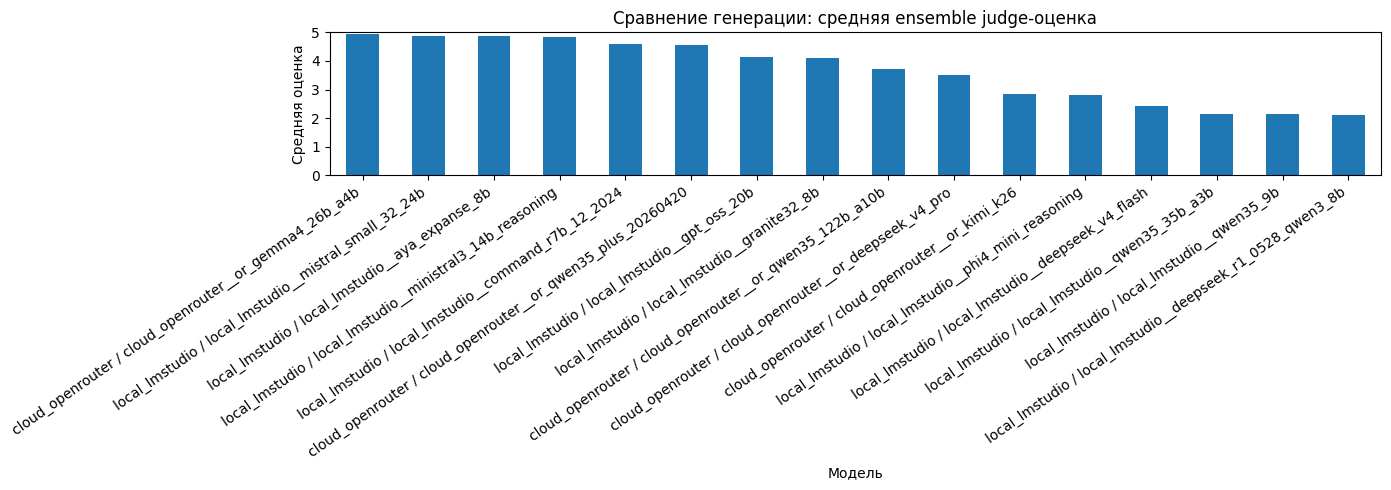

In [24]:
plot_ensemble_summary_by_model(ensemble_summary_by_model)

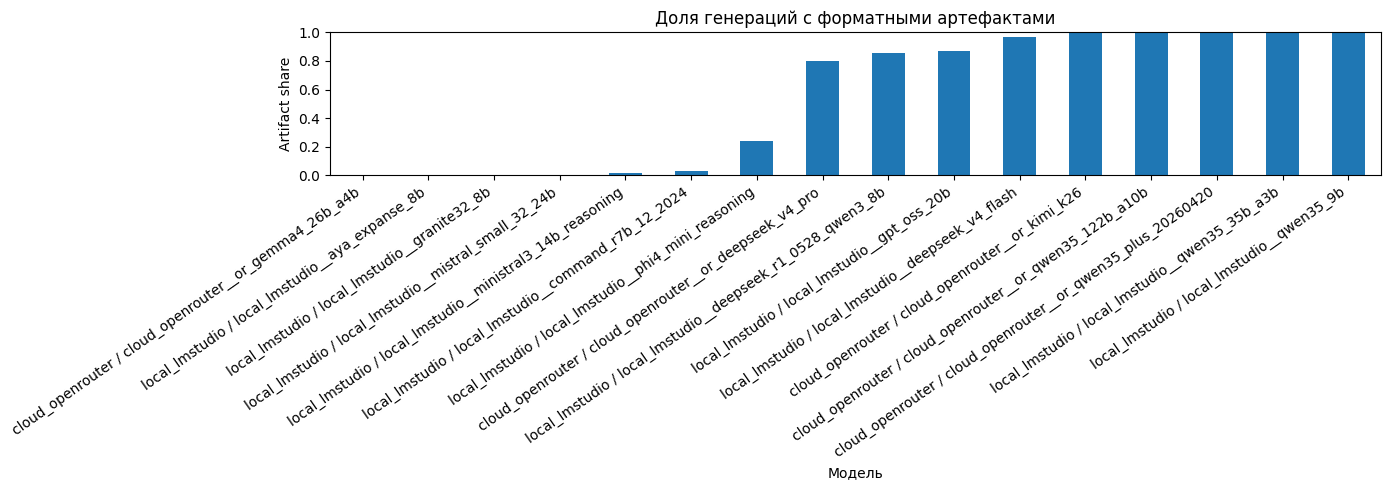

In [26]:
plot_artifact_share(combined_artifact_summary)

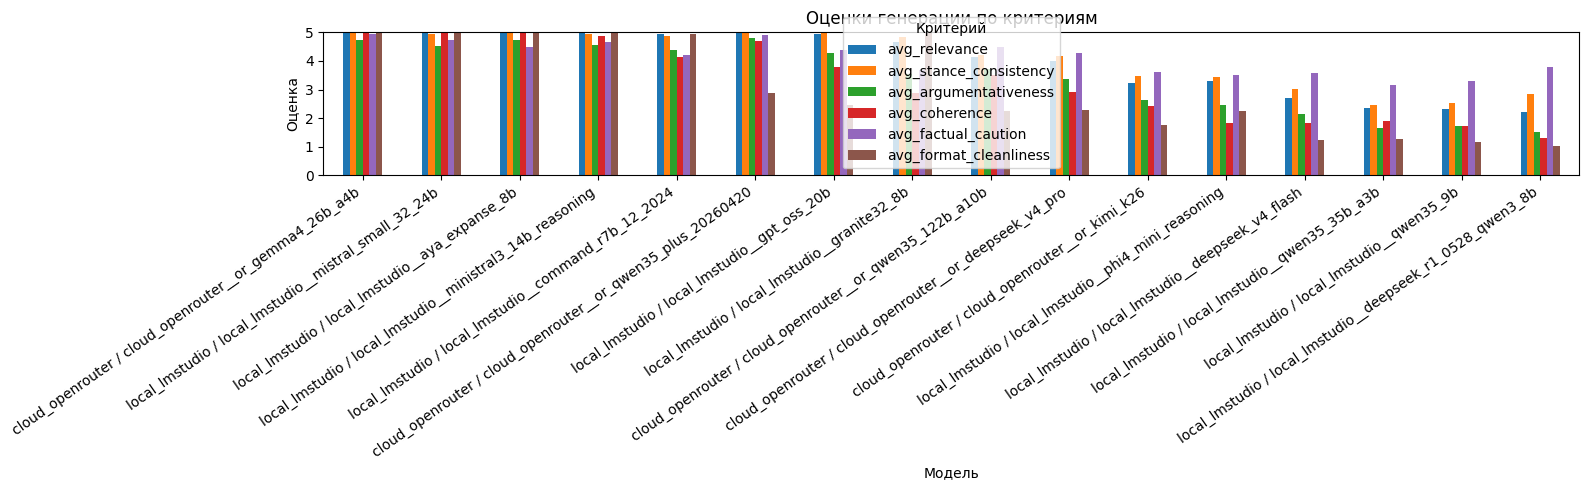

In [28]:
plot_criteria_by_model(ensemble_summary_by_model)

**лучшие и худшие аргументы по ensemble-оценке**

In [29]:
best_examples = ensemble_argument_scores.sort_values("avg_mean_score", ascending=False).head(20)
worst_examples = ensemble_argument_scores.sort_values("avg_mean_score", ascending=True).head(20)

In [30]:
print("Лучшие аргументы:")
display(
    best_examples[
        [
            "source_backend",
            "generated_by_model",
            "topic",
            "stance",
            "avg_mean_score",
            "generated_argument",
        ]
    ]
)

Лучшие аргументы:


,source_backend,generated_by_model,topic,stance,avg_mean_score,generated_argument
1512,local_lmstudio,local_lmstudio__mistral_small_32_24b,quarantine,FOR,5.0,Карантин снижает скорость распространения инфе...
185,cloud_openrouter,cloud_openrouter__or_gemma4_26b_a4b,quarantine,FOR,5.0,Ограничение физических контактов в период эпид...
188,cloud_openrouter,cloud_openrouter__or_gemma4_26b_a4b,quarantine,FOR,5.0,Соблюдение карантинных мер позволяет ограничит...
189,cloud_openrouter,cloud_openrouter__or_gemma4_26b_a4b,quarantine,FOR,5.0,Соблюдение карантинных мер позволяет ограничит...
190,cloud_openrouter,cloud_openrouter__or_gemma4_26b_a4b,quarantine,FOR,5.0,Ограничение физических контактов в период эпид...
192,cloud_openrouter,cloud_openrouter__or_gemma4_26b_a4b,quarantine,FOR,5.0,Введение карантинных мер позволяет ограничить ...
193,cloud_openrouter,cloud_openrouter__or_gemma4_26b_a4b,quarantine,FOR,5.0,Соблюдение карантинных мер позволяет существен...
194,cloud_openrouter,cloud_openrouter__or_gemma4_26b_a4b,quarantine,FOR,5.0,Соблюдение карантинных мер позволяет замедлить...
195,cloud_openrouter,cloud_openrouter__or_gemma4_26b_a4b,quarantine,FOR,5.0,Ограничение социальных контактов в период эпид...
196,cloud_openrouter,cloud_openrouter__or_gemma4_26b_a4b,quarantine,FOR,5.0,Соблюдение карантинных мер позволяет ограничит...


In [31]:
print("Худшие аргументы:")
display(
    worst_examples[
        [
            "source_backend",
            "generated_by_model",
            "topic",
            "stance",
            "avg_mean_score",
            "generated_argument",
        ]
    ]
)

Худшие аргументы:


,source_backend,generated_by_model,topic,stance,avg_mean_score,generated_argument
394,cloud_openrouter,cloud_openrouter__or_qwen35_122b_a10b,masks,FOR,1.000000,Thinking Process: 1. **Analyze the Request:** ...
1841,local_lmstudio,local_lmstudio__qwen35_9b,quarantine,AGAINST,1.000000,Thinking Process: 1. **Analyze the Request:** ...
964,local_lmstudio,local_lmstudio__deepseek_v4_flash,masks,AGAINST,1.000000,Thinking Process: 1. **Analyze the Request:** ...
1786,local_lmstudio,local_lmstudio__qwen35_35b_a3b,vaccines,FOR,1.000000,Thinking Process: 1. **Analyze the Request:** ...
1766,local_lmstudio,local_lmstudio__qwen35_35b_a3b,vaccines,AGAINST,1.000000,Thinking Process: 1. **Analyze the Request:** ...
1851,local_lmstudio,local_lmstudio__qwen35_9b,quarantine,AGAINST,1.000000,Thinking Process: 1. **Analyze the Request:** ...
1762,local_lmstudio,local_lmstudio__qwen35_35b_a3b,vaccines,AGAINST,1.000000,Thinking Process: 1. **Analyze the Request:** ...
985,local_lmstudio,local_lmstudio__deepseek_v4_flash,masks,FOR,1.000000,Thinking Process: 1. **Analyze the Request:** ...
1889,local_lmstudio,local_lmstudio__qwen35_9b,vaccines,AGAINST,1.000000,Thinking Process: 1. **Analyze the Request:** ...
881,local_lmstudio,local_lmstudio__deepseek_r1_0528_qwen3_8b,quarantine,AGAINST,1.250000,"Хм, пользователь просит создать аргумент проти..."


In [32]:
best_examples.to_csv(
    COMBINED_JUDGE_DIR / "best_generated_arguments.csv",
    index=False,
    encoding="utf-8-sig",
)

worst_examples.to_csv(
    COMBINED_JUDGE_DIR / "worst_generated_arguments.csv",
    index=False,
    encoding="utf-8-sig",
)

**сохранение результатов**

In [33]:
import shutil

archive_path = shutil.make_archive(
    str(COMBINED_RESULTS_DIR),
    "zip",
    COMBINED_RESULTS_DIR,
)

print("Архив создан:", archive_path)


Архив создан: C:\Users\zykan\Downloads\vkr\Judge\combined_results\results_vkr_combined_judge.zip
